# Decisions and Uncertainty

The methodology used to assess models fits into the broader framework of **statistical hypothesis testing**. In this section we describe the standard steps of a hypothesis test using Gregor Mendel's famous pea plant experiments.

In [1]:
import pandas as pd
%matplotlib inline
path_data = "../../../assets/data/"
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
import numpy as np

Gregor Mendel proposed that each pea plant in a particular variety had a 75% chance of producing purple flowers and a 25% chance of producing white flowers, independently of other plants. Among 929 plants, 705 had purple flowers. We will assess whether these data are consistent with Mendel's model.

## Step 1: The Hypotheses

**Null hypothesis:** Each plant independently has a 75% chance of purple flowers and a 25% chance of white flowers.

**Alternative hypothesis:** Mendel's model is not correct for this population of plants.

The null hypothesis is a chance model from which we can simulate data.

## Step 2: The Test Statistic

Our test statistic is the distance between the sample percentage of purple-flowering plants and the 75% predicted by Mendel's model:

$$| \text{sample percent purple} - 75|$$

Large values favor the alternative hypothesis, while small values are consistent with the null hypothesis.

In [2]:
observed_statistic = abs(100*(705/929) - 75)
observed_statistic

0.8880516684607045

## Step 3: Distribution of the Test Statistic Under the Null Hypothesis

We simulate many random samples under Mendel's model and calculate the test statistic for each sample.

In [3]:
def sample_proportions(sample_size, proportions):
    categories = np.arange(len(proportions))
    sample = np.random.choice(categories, size=sample_size, p=proportions)
    counts = np.bincount(sample, minlength=len(proportions))
    return counts / sample_size

In [4]:
mendel_proportions = np.array([0.75, 0.25])
mendel_proportion_purple = mendel_proportions[0]
sample_size = 929

In [12]:
def one_simulated_distance():
    sample_proportion_purple = sample_proportions(sample_size, mendel_proportions)[0]
    return 100 * abs(sample_proportion_purple - mendel_proportion_purple)

In [16]:
one_simulated_distance()

np.float64(1.7491926803014035)

In [17]:
repetitions = 10000
distances = np.array([])
for i in np.arange(repetitions):
    distances = np.append(distances, one_simulated_distance())

In [18]:
distances

array([0.08073197, 1.21097955, 0.1883746 , ..., 0.72658773, 1.31862217,
       0.67276642], shape=(10000,))

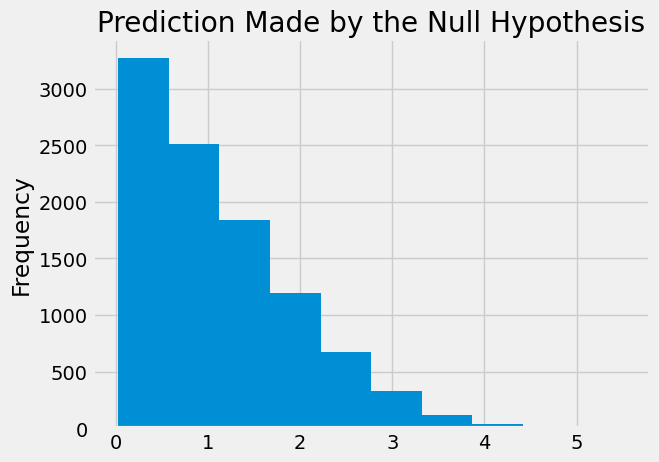

In [23]:
pd.DataFrame({'Distance between Sample percent and 75%': distances})['Distance between Sample percent and 75%'].plot.hist()
plt.title('Prediction Made by the Null Hypothesis')

plt.show()

The histogram displays the distribution of the test statistic predicted by the null hypothesis.

## Step 4: Conclusion of the Test

We compare the observed statistic to the simulated distribution.

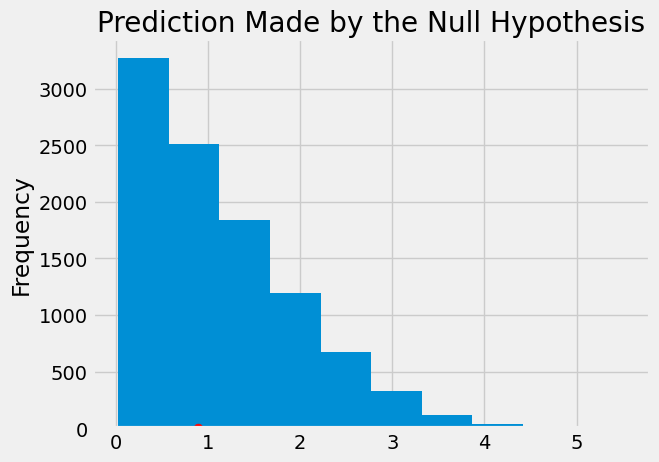

In [24]:
pd.DataFrame({'Distance between Sample percent and 75%': distances})['Distance between Sample percent and 75%'].plot.hist()
plt.title('Prediction Made by the Null Hypothesis')
plt.scatter(observed_statistic,0,color='red',s=40)
plt.show()

The observed statistic lies well within the range predicted by Mendel's model. Therefore, the data are consistent with the null hypothesis.

## The Meaning of Consistency

Whether an observed statistic is consistent with a model involves judgment. In obvious cases the conclusion is clear, but in borderline cases we often quantify the evidence using a p-value.

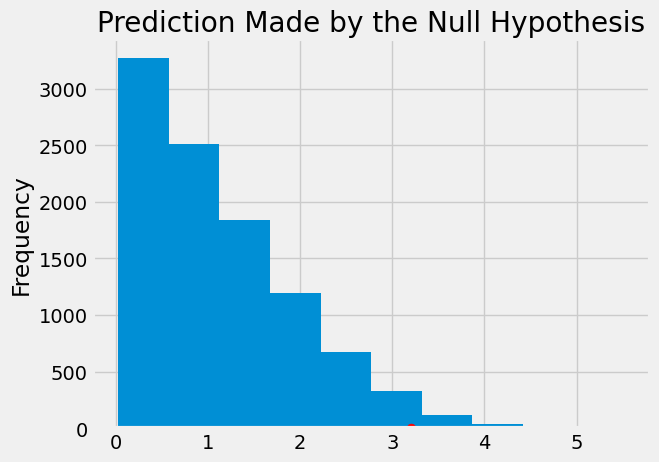

In [25]:
different_observed_statistic = 3.2
pd.DataFrame({'Distance between Sample % and 75%': distances})['Distance between Sample % and 75%'].plot.hist()
#plt.ylim(-0.02,0.5)
plt.title('Prediction Made by the Null Hypothesis')
plt.scatter(different_observed_statistic,0,color='red',s=40)
plt.show()

## Conventional Cutoffs and the p-Value

The p-value is the probability, under the null hypothesis, of observing the test statistic or a more extreme value in the direction favoring the alternative hypothesis.

In [26]:
np.count_nonzero(distances >= different_observed_statistic) / repetitions

np.float64(0.0241)

A p-value below 5% is conventionally called statistically significant, and a p-value below 1% is often called highly statistically significant.

When reporting results, it is good practice to provide both the observed statistic and the p-value rather than reporting only whether the result is statistically significant.

## Historical Note on the Conventions

The commonly used 5% cutoff originated with the work of Sir Ronald Fisher in the early twentieth century. Although the threshold became standard practice, it was originally proposed as a convenient convention rather than a universal law. Statistical significance should therefore be interpreted thoughtfully and in context.